
> **Course: AIML ZG528 AI and ML for Robotics**

>  **Author: Sangeetha Viswanathan**
sangeetha.viswanathan@pilani.bits-pilani.ac.in

> **Objective**: Implement Visual SLAM using Convolution Neural Network.

In [ ]:
# Install PyBullet
!pip install pybullet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pybullet: filename=pybullet-3.2.7-cp312-cp312-linux_x86_64.whl size=99873451 sha256=d4f8eba8b5087d271aca174b45bdbfc14cf903ab96984e9404bc67c89610666d
  Stored in directory: /root/.cache/pip/wheels/72/95/1d/b336e5ee612ae9a019bfff4dc0bedd100ee6f0570db205fdf8
Successfully built pybullet


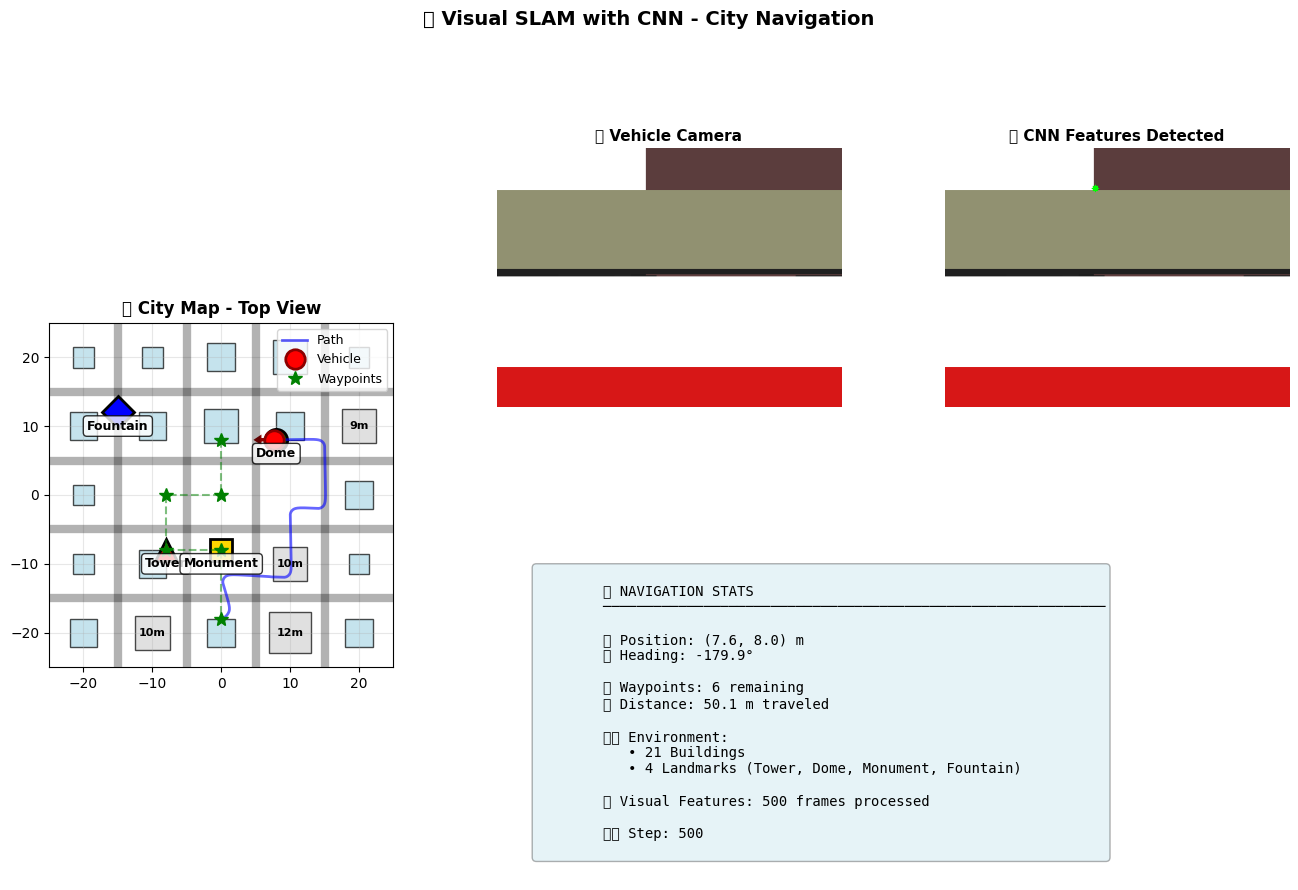

In [ ]:
"""
Visual SLAM with CNN - Colab Optimized Version
Google Colab ready - no X Window needed
"""

# Installation commands for Colab
print("📦 Installing required packages...")
print("Run these commands in Colab:")
print("!pip install -q pybullet opencv-python matplotlib numpy")
print("-"*70)

import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyBboxPatch, Polygon
import cv2
from collections import deque
from IPython import display
import time

class SimpleCNN:
    """Lightweight feature extractor using ORB"""
    def __init__(self):
        self.feature_detector = cv2.ORB_create(nfeatures=50)

    def extract_features(self, image):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image
        keypoints, descriptors = self.feature_detector.detectAndCompute(gray, None)
        return keypoints, descriptors


class CityBuilder:
    """Build realistic city environment"""
    def __init__(self):
        self.buildings = []
        self.landmarks = []

    def build(self):
        print("🏗️  Building city...")

        # Ground
        ground = p.createCollisionShape(p.GEOM_BOX, halfExtents=[50, 50, 0.1])
        ground_visual = p.createVisualShape(p.GEOM_BOX, halfExtents=[50, 50, 0.1],
                                           rgbaColor=[0.3, 0.3, 0.3, 1])
        p.createMultiBody(0, ground, ground_visual, [0, 0, -0.1])

        # Roads
        self._create_roads()

        # Buildings
        self._create_buildings()

        # Landmarks
        self._create_landmarks()

        print(f"✅ City ready: {len(self.buildings)} buildings, {len(self.landmarks)} landmarks")

    def _create_roads(self):
        """Create road grid"""
        road_color = [0.2, 0.2, 0.2, 1]
        road_width = 2.0

        # Horizontal roads at y = -15, -5, 5, 15
        for y in [-15, -5, 5, 15]:
            vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[25, road_width/2, 0.05],
                                     rgbaColor=road_color)
            p.createMultiBody(0, baseVisualShapeIndex=vis, basePosition=[0, y, 0.05])

            # Road markings
            for x in range(-20, 21, 4):
                mark_vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[0.3, 0.1, 0.06],
                                              rgbaColor=[1, 1, 1, 1])
                p.createMultiBody(0, baseVisualShapeIndex=mark_vis, basePosition=[x, y, 0.11])

        # Vertical roads at x = -15, -5, 5, 15
        for x in [-15, -5, 5, 15]:
            vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[road_width/2, 25, 0.05],
                                     rgbaColor=road_color)
            p.createMultiBody(0, baseVisualShapeIndex=vis, basePosition=[x, 0, 0.05])

    def _create_buildings(self):
        """Create buildings with different heights"""
        configs = [
            # Downtown (tall buildings)
            (10, -20, 6, 12, [0.2, 0.2, 0.4, 1]),
            (10, -10, 5, 10, [0.3, 0.3, 0.5, 1]),
            (10, 10, 4, 8, [0.25, 0.25, 0.45, 1]),

            # Mid-rise commercial
            (-10, -20, 5, 10, [0.3, 0.3, 0.5, 1]),
            (0, -20, 4, 8, [0.5, 0.5, 0.6, 1]),
            (20, -20, 4, 6, [0.5, 0.5, 0.5, 1]),
            (20, -10, 3, 5, [0.6, 0.6, 0.6, 1]),
            (20, 10, 5, 9, [0.3, 0.4, 0.5, 1]),

            # Residential areas
            (-20, -20, 4, 6, [0.6, 0.4, 0.2, 1]),
            (-20, -10, 3, 5, [0.7, 0.5, 0.3, 1]),
            (-20, 0, 3, 5, [0.7, 0.5, 0.3, 1]),
            (-20, 10, 4, 7, [0.4, 0.4, 0.6, 1]),
            (-20, 20, 3, 4, [0.6, 0.6, 0.4, 1]),

            (-10, -10, 4, 6, [0.5, 0.4, 0.3, 1]),
            (-10, 10, 4, 5, [0.6, 0.5, 0.4, 1]),
            (-10, 20, 3, 7, [0.4, 0.5, 0.5, 1]),

            (0, 10, 5, 6, [0.6, 0.4, 0.4, 1]),
            (0, 20, 4, 5, [0.5, 0.6, 0.5, 1]),

            (10, 20, 5, 8, [0.4, 0.4, 0.5, 1]),
            (20, 0, 4, 7, [0.4, 0.5, 0.6, 1]),
            (20, 20, 3, 4, [0.7, 0.5, 0.4, 1]),
        ]

        for x, y, size, height, color in configs:
            # Main building
            col = p.createCollisionShape(p.GEOM_BOX, halfExtents=[size/2, size/2, height/2])
            vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[size/2, size/2, height/2],
                                     rgbaColor=color)
            building = p.createMultiBody(0, col, vis, [x, y, height/2])
            self.buildings.append({'pos': [x, y], 'size': size, 'height': height})

            # Windows
            window_color = [0.3, 0.5, 0.7, 1]
            num_floors = int(height / 1.5)
            for floor in range(1, num_floors):
                for i in [-1, 0, 1]:
                    if abs(i * 0.8) < size/2 - 0.3:
                        win_vis = p.createVisualShape(p.GEOM_BOX,
                                                     halfExtents=[0.2, 0.05, 0.3],
                                                     rgbaColor=window_color)
                        p.createMultiBody(0, baseVisualShapeIndex=win_vis,
                                        basePosition=[x + i*0.8, y + size/2 + 0.05, floor*1.5])

    def _create_landmarks(self):
        """Create distinctive landmarks"""
        # 1. Red Tower with antenna
        tower_x, tower_y = -8, -8
        col = p.createCollisionShape(p.GEOM_CYLINDER, radius=1.5, height=15)
        vis = p.createVisualShape(p.GEOM_CYLINDER, radius=1.5, length=15,
                                 rgbaColor=[0.8, 0.2, 0.2, 1])
        p.createMultiBody(0, col, vis, [tower_x, tower_y, 7.5])

        # Antenna
        antenna_vis = p.createVisualShape(p.GEOM_CYLINDER, radius=0.1, length=5,
                                         rgbaColor=[0.9, 0.9, 0.9, 1])
        p.createMultiBody(0, baseVisualShapeIndex=antenna_vis,
                        basePosition=[tower_x, tower_y, 17.5])
        self.landmarks.append({'type': 'Tower', 'pos': [tower_x, tower_y], 'color': 'red'})

        # 2. Green Dome
        dome_x, dome_y = 8, 8
        base_vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[3, 3, 2],
                                      rgbaColor=[0.9, 0.9, 0.7, 1])
        p.createMultiBody(0, baseVisualShapeIndex=base_vis, basePosition=[dome_x, dome_y, 2])

        dome_col = p.createCollisionShape(p.GEOM_SPHERE, radius=2.5)
        dome_vis = p.createVisualShape(p.GEOM_SPHERE, radius=2.5,
                                      rgbaColor=[0.2, 0.7, 0.3, 1])
        p.createMultiBody(0, dome_col, dome_vis, [dome_x, dome_y, 5.5])
        self.landmarks.append({'type': 'Dome', 'pos': [dome_x, dome_y], 'color': 'green'})

        # 3. Monument (obelisk)
        mon_x, mon_y = 0, -8
        mon_col = p.createCollisionShape(p.GEOM_BOX, halfExtents=[0.8, 0.8, 10])
        mon_vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[0.8, 0.8, 10],
                                     rgbaColor=[0.8, 0.8, 0.9, 1])
        p.createMultiBody(0, mon_col, mon_vis, [mon_x, mon_y, 10])

        # Pyramid top
        pyr_vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[1, 1, 1],
                                     rgbaColor=[0.9, 0.8, 0.3, 1])
        p.createMultiBody(0, baseVisualShapeIndex=pyr_vis, basePosition=[mon_x, mon_y, 21])
        self.landmarks.append({'type': 'Monument', 'pos': [mon_x, mon_y], 'color': 'gold'})

        # 4. Fountain (blue)
        fount_x, fount_y = -15, 12
        fount_vis = p.createVisualShape(p.GEOM_CYLINDER, radius=2, length=1,
                                       rgbaColor=[0.2, 0.4, 0.8, 1])
        p.createMultiBody(0, baseVisualShapeIndex=fount_vis,
                        basePosition=[fount_x, fount_y, 0.5])

        # Water jets
        for i in range(3):
            jet_vis = p.createVisualShape(p.GEOM_SPHERE, radius=0.3,
                                         rgbaColor=[0.5, 0.7, 1, 0.7])
            p.createMultiBody(0, baseVisualShapeIndex=jet_vis,
                            basePosition=[fount_x + (i-1)*0.8, fount_y, 1.5])
        self.landmarks.append({'type': 'Fountain', 'pos': [fount_x, fount_y], 'color': 'blue'})


class AutonomousVehicle:
    """Self-driving car with camera"""
    def __init__(self):
        # Create vehicle body
        body_col = p.createCollisionShape(p.GEOM_BOX, halfExtents=[1.0, 0.5, 0.3])
        body_vis = p.createVisualShape(p.GEOM_BOX, halfExtents=[1.0, 0.5, 0.3],
                                      rgbaColor=[0.9, 0.1, 0.1, 1])
        self.vehicle = p.createMultiBody(10, body_col, body_vis, [0, -18, 0.5])

        # Camera params
        self.cam_width = 320
        self.cam_height = 240

        # Navigation
        self.waypoints = deque()
        self.path_history = [[0, -18]]

        # CNN feature extractor
        self.cnn = SimpleCNN()
        self.feature_count_history = []

    def get_camera_image(self):
        """Capture RGB image from vehicle camera"""
        pos, orn = p.getBasePositionAndOrientation(self.vehicle)
        rot_mat = np.array(p.getMatrixFromQuaternion(orn)).reshape(3, 3)

        # Camera position
        cam_offset = np.array([0.5, 0, 0.5])
        cam_pos = pos + rot_mat @ cam_offset

        # Look forward
        target_offset = np.array([5, 0, 0])
        target = cam_pos + rot_mat @ target_offset

        # Up vector
        up = rot_mat @ np.array([0, 0, 1])

        # Matrices
        view_mat = p.computeViewMatrix(cam_pos, target, up)
        proj_mat = p.computeProjectionMatrixFOV(60, self.cam_width/self.cam_height, 0.1, 100)

        # Capture
        _, _, rgb, depth, _ = p.getCameraImage(self.cam_width, self.cam_height,
                                               view_mat, proj_mat,
                                               renderer=p.ER_BULLET_HARDWARE_OPENGL)

        rgb_array = np.array(rgb, dtype=np.uint8).reshape(self.cam_height, self.cam_width, 4)
        return rgb_array[:, :, :3]  # Remove alpha

    def move(self, velocity, steering):
        """Move vehicle"""
        pos, orn = p.getBasePositionAndOrientation(self.vehicle)
        euler = p.getEulerFromQuaternion(orn)

        new_yaw = euler[2] + steering * 0.1
        new_orn = p.getQuaternionFromEuler([0, 0, new_yaw])

        dx = velocity * np.cos(new_yaw) * 0.1
        dy = velocity * np.sin(new_yaw) * 0.1
        new_pos = [pos[0] + dx, pos[1] + dy, pos[2]]

        p.resetBasePositionAndOrientation(self.vehicle, new_pos, new_orn)
        self.path_history.append([new_pos[0], new_pos[1]])

    def get_position(self):
        pos, orn = p.getBasePositionAndOrientation(self.vehicle)
        euler = p.getEulerFromQuaternion(orn)
        return np.array([pos[0], pos[1], euler[2]])

    def navigate_to_waypoint(self):
        """Simple navigation controller"""
        if len(self.waypoints) == 0:
            return 0, 0, True

        target = self.waypoints[0]
        pos = self.get_position()

        dx = target[0] - pos[0]
        dy = target[1] - pos[1]
        distance = np.sqrt(dx**2 + dy**2)

        if distance < 1.0:
            self.waypoints.popleft()
            if len(self.waypoints) == 0:
                return 0, 0, True

        desired_angle = np.arctan2(dy, dx)
        angle_diff = desired_angle - pos[2]

        # Normalize
        while angle_diff > np.pi:
            angle_diff -= 2 * np.pi
        while angle_diff < -np.pi:
            angle_diff += 2 * np.pi

        velocity = min(1.0, distance / 2.0)
        steering = np.clip(angle_diff * 2.0, -1.0, 1.0)

        return velocity, steering, False


class CityNavigationSLAM:
    """Main SLAM system"""
    def __init__(self):
        # Connect to PyBullet (DIRECT mode for Colab)
        p.connect(p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0, 0, -10)

        # Build environment
        self.city = CityBuilder()
        self.city.build()

        # Create vehicle
        self.vehicle = AutonomousVehicle()

        print("🚗 Vehicle ready")

    def visualize(self, camera_img, features_img, step):
        """Create comprehensive visualization"""
        fig = plt.figure(figsize=(16, 10))
        gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

        # 1. City map
        ax_map = fig.add_subplot(gs[:, 0])
        ax_map.set_xlim(-25, 25)
        ax_map.set_ylim(-25, 25)
        ax_map.set_aspect('equal')
        ax_map.grid(True, alpha=0.3)
        ax_map.set_title('🗺️ City Map - Top View', fontweight='bold', fontsize=12)

        # Roads
        for y in [-15, -5, 5, 15]:
            ax_map.plot([-25, 25], [y, y], 'k-', linewidth=6, alpha=0.3)
        for x in [-15, -5, 5, 15]:
            ax_map.plot([x, x], [-25, 25], 'k-', linewidth=6, alpha=0.3)

        # Buildings
        for b in self.city.buildings:
            x, y, size, h = b['pos'][0], b['pos'][1], b['size'], b['height']
            color = 'lightgray' if h > 8 else 'lightblue'
            rect = Rectangle((x-size/2, y-size/2), size, size,
                           facecolor=color, edgecolor='black', linewidth=1, alpha=0.7)
            ax_map.add_patch(rect)
            if h > 8:
                ax_map.text(x, y, f'{int(h)}m', ha='center', va='center',
                          fontsize=8, fontweight='bold')

        # Landmarks
        markers = {'Tower': '^', 'Dome': 'o', 'Monument': 's', 'Fountain': 'D'}
        colors = {'Tower': 'red', 'Dome': 'green', 'Monument': 'gold', 'Fountain': 'blue'}

        for lm in self.city.landmarks:
            x, y = lm['pos']
            ax_map.plot(x, y, markers[lm['type']], markersize=16,
                       color=colors[lm['type']], markeredgecolor='black', markeredgewidth=2)
            ax_map.text(x, y-2.5, lm['type'], ha='center', fontsize=9, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        # Vehicle path
        if len(self.vehicle.path_history) > 1:
            path = np.array(self.vehicle.path_history)
            ax_map.plot(path[:, 0], path[:, 1], 'b-', linewidth=2, alpha=0.6, label='Path')

        # Vehicle position
        pos = self.vehicle.get_position()
        ax_map.plot(pos[0], pos[1], 'ro', markersize=14, markeredgecolor='darkred',
                   markeredgewidth=2, label='Vehicle')

        # Orientation
        arrow_len = 2
        dx = arrow_len * np.cos(pos[2])
        dy = arrow_len * np.sin(pos[2])
        ax_map.arrow(pos[0], pos[1], dx, dy, head_width=0.8, head_length=0.6,
                    fc='red', ec='darkred', linewidth=2)

        # Waypoints
        if len(self.vehicle.waypoints) > 0:
            wp = np.array(list(self.vehicle.waypoints))
            ax_map.plot(wp[:, 0], wp[:, 1], 'g*', markersize=10, label='Waypoints')
            ax_map.plot(wp[:, 0], wp[:, 1], 'g--', linewidth=1.5, alpha=0.5)

        ax_map.legend(loc='upper right', fontsize=9)

        # 2. Camera view
        ax_cam = fig.add_subplot(gs[0, 1])
        if camera_img is not None:
            ax_cam.imshow(camera_img)
        ax_cam.set_title('📷 Vehicle Camera', fontweight='bold', fontsize=11)
        ax_cam.axis('off')

        # 3. Features
        ax_feat = fig.add_subplot(gs[0, 2])
        if features_img is not None:
            ax_feat.imshow(features_img)
        ax_feat.set_title('🔍 CNN Features Detected', fontweight='bold', fontsize=11)
        ax_feat.axis('off')

        # 4. Stats
        ax_stats = fig.add_subplot(gs[1, 1:])
        ax_stats.axis('off')

        stats_text = f"""
        📊 NAVIGATION STATS
        {'─'*60}

         Position: ({pos[0]:.1f}, {pos[1]:.1f}) m
         Heading: {np.degrees(pos[2]):.1f}°

         Waypoints: {len(self.vehicle.waypoints)} remaining
        Distance: {len(self.vehicle.path_history) * 0.1:.1f} m traveled

         Environment:
           • {len(self.city.buildings)} Buildings
           • {len(self.city.landmarks)} Landmarks (Tower, Dome, Monument, Fountain)

        🔬 Visual Features: {len(self.vehicle.feature_count_history)} frames processed

        ⏱️ Step: {step}
        """

        ax_stats.text(0.05, 0.5, stats_text, transform=ax_stats.transAxes,
                     fontsize=10, verticalalignment='center', fontfamily='monospace',
                     bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

        fig.suptitle('🌆 Visual SLAM with CNN - City Navigation',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        return fig

    def run(self, duration=50, update_interval=2):
        """Run simulation"""
        print("\n🚀 Starting navigation...")
        print("─"*70)

        # Define tour route
        waypoints = [
            [0, -12], [10, -12], [10, -2], [15, -2],
            [15, 8], [8, 8], [0, 8], [0, 0],
            [-8, 0], [-8, -8], [0, -8], [0, -18]
        ]

        self.vehicle.waypoints = deque(waypoints)
        print(f"🗺️ Route: {len(waypoints)} waypoints")
        print("─"*70 + "\n")

        dt = 0.1
        steps = int(duration / dt)
        update_every = int(update_interval / dt)

        for step in range(steps):
            # Navigate
            vel, steer, done = self.vehicle.navigate_to_waypoint()
            if done:
                print("\n✅ All waypoints reached!")
                break

            # Move
            self.vehicle.move(vel, steer)

            # Camera & features
            cam_img = self.vehicle.get_camera_image()
            kp, desc = self.vehicle.cnn.extract_features(cam_img)

            # Visualize features
            feat_img = cam_img.copy()
            for k in kp:
                x, y = int(k.pt[0]), int(k.pt[1])
                cv2.circle(feat_img, (x, y), 3, (0, 255, 0), -1)

            self.vehicle.feature_count_history.append(len(kp))

            # Update display
            if step % update_every == 0:
                display.clear_output(wait=True)
                fig = self.visualize(cam_img, feat_img, step)
                plt.show()

                pos = self.vehicle.get_position()
                print(f"⏱️ {step*dt:5.1f}s | Pos: ({pos[0]:6.1f}, {pos[1]:6.1f}) | "
                      f"Features: {len(kp):3d} | WP: {len(self.vehicle.waypoints)}")

            p.stepSimulation()
            time.sleep(dt)

        print("\n" + "="*70)
        print("✅ SIMULATION COMPLETE")
        print("="*70)

        # Final view
        display.clear_output(wait=True)
        fig = self.visualize(cam_img, feat_img, steps)
        plt.show()

        p.disconnect()


# RUN SIMULATION
if __name__ == "__main__":
    print("\n" + "="*70)
    print("VISUAL SLAM WITH CNN - CITY NAVIGATION")
    print("="*70)
    print("\n Features:")
    print("  • Realistic city with buildings, roads, and landmarks")
    print("  • CNN-based feature extraction (ORB features)")
    print("  • Autonomous navigation through waypoints")
    print("  • Multi-view real-time visualization")
    print("\n📍 Landmarks:")
    print("  🔴 Red Tower - Communication tower with antenna")
    print("  🟢 Green Dome - Capitol building")
    print("  🟡 Monument - Obelisk memorial")
    print("  🔵 Fountain - Water feature")
    print("="*70 + "\n")

    slam = CityNavigationSLAM()
    slam.run(duration=50, update_interval=2)

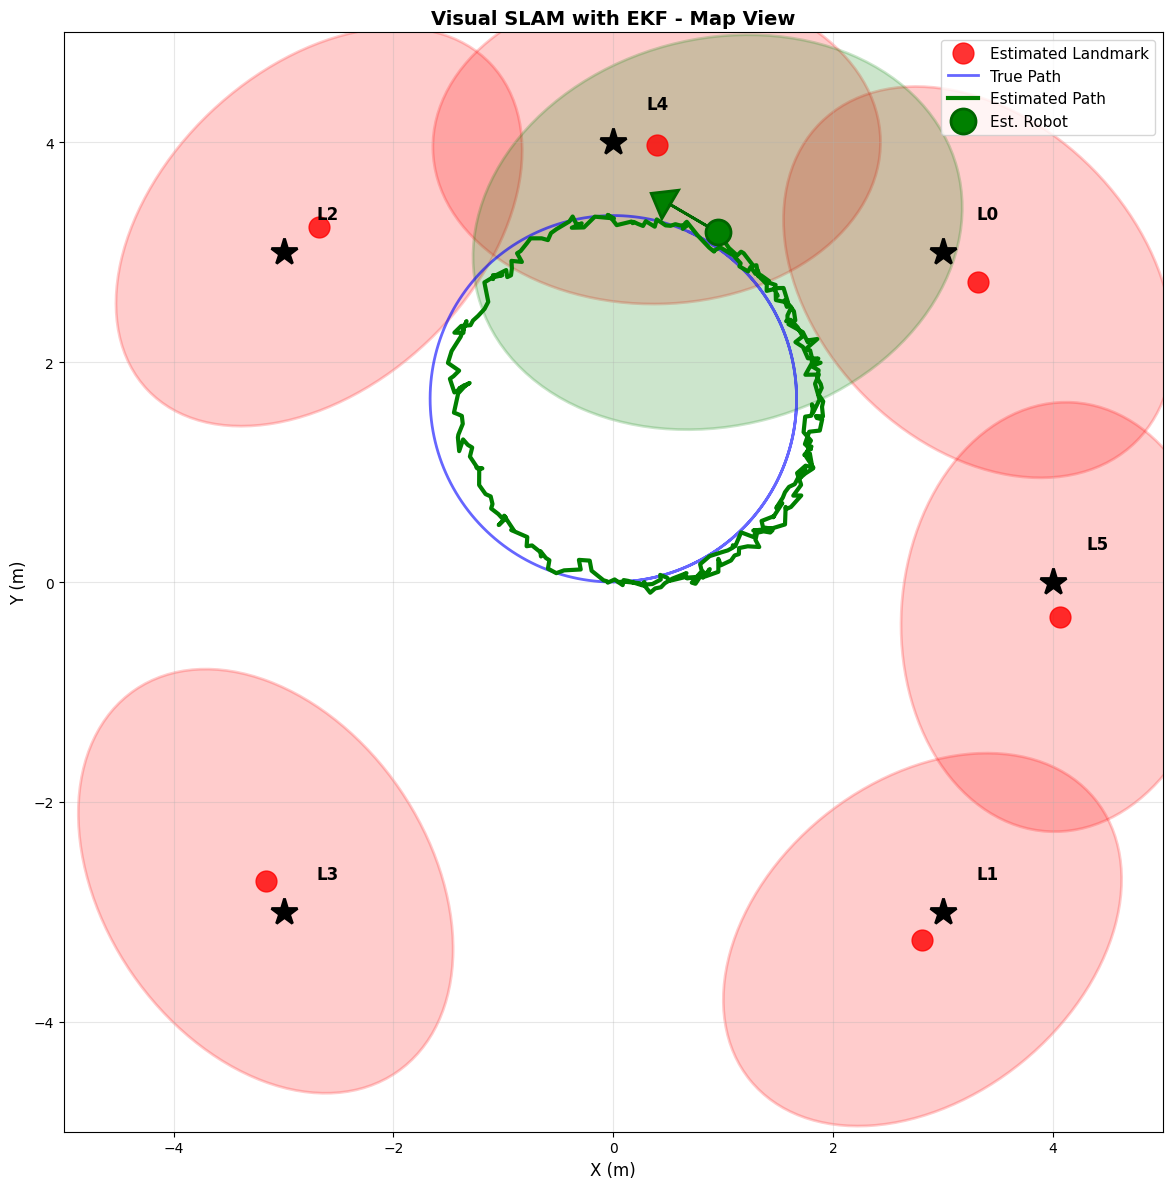

🧹 Cleanup complete


In [ ]:
# Visual SLAM with EKF - Google Colab Setup

"""
Run this in Google Colab for Visual SLAM demonstration.
No X Window System needed - uses matplotlib for visualization only.
"""

# STEP 1: Install required packages
print("Installing required packages...")
!pip install -q pybullet numpy matplotlib

# STEP 2: Import and run the simulation
import pybullet as p
import pybullet_data
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import time
from IPython import display

class EKF_SLAM:
    """Extended Kalman Filter for SLAM"""

    def __init__(self):
        # State: [x, y, theta, landmark1_x, landmark1_y, landmark2_x, landmark2_y, ...]
        self.state = np.array([0.0, 0.0, 0.0])  # x, y, theta
        self.P = np.eye(3) * 0.1
        self.Q = np.diag([0.1, 0.1, 0.05])
        self.R = np.diag([0.2, 0.1])
        self.landmark_ids = {}
        self.num_landmarks = 0

    def predict(self, v, w, dt):
        """Prediction step based on motion model"""
        x, y, theta = self.state[0], self.state[1], self.state[2]

        if abs(w) < 1e-6:
            x_new = x + v * dt * np.cos(theta)
            y_new = y + v * dt * np.sin(theta)
            theta_new = theta
        else:
            x_new = x + (v/w) * (np.sin(theta + w*dt) - np.sin(theta))
            y_new = y + (v/w) * (-np.cos(theta + w*dt) + np.cos(theta))
            theta_new = theta + w * dt

        self.state[0] = x_new
        self.state[1] = y_new
        self.state[2] = self.normalize_angle(theta_new)

        G = np.eye(len(self.state))
        if abs(w) < 1e-6:
            G[0, 2] = -v * dt * np.sin(theta)
            G[1, 2] = v * dt * np.cos(theta)
        else:
            G[0, 2] = (v/w) * (np.cos(theta + w*dt) - np.cos(theta))
            G[1, 2] = (v/w) * (np.sin(theta + w*dt) - np.sin(theta))

        Q_full = np.zeros((len(self.state), len(self.state)))
        Q_full[0:3, 0:3] = self.Q
        self.P = G @ self.P @ G.T + Q_full

    def update(self, observations):
        """Update step based on landmark observations"""
        for obs in observations:
            landmark_id, measured_range, measured_bearing = obs
            if landmark_id not in self.landmark_ids:
                self.add_new_landmark(landmark_id, measured_range, measured_bearing)
            else:
                self.update_landmark(landmark_id, measured_range, measured_bearing)

    def add_new_landmark(self, landmark_id, r, phi):
        """Add a new landmark to the state"""
        x, y, theta = self.state[0], self.state[1], self.state[2]
        lm_x = x + r * np.cos(theta + phi)
        lm_y = y + r * np.sin(theta + phi)

        self.state = np.append(self.state, [lm_x, lm_y])
        self.landmark_ids[landmark_id] = self.num_landmarks
        self.num_landmarks += 1

        n = len(self.state)
        P_new = np.zeros((n, n))
        P_new[:-2, :-2] = self.P
        P_new[-2, -2] = 1000
        P_new[-1, -1] = 1000
        self.P = P_new

    def update_landmark(self, landmark_id, measured_range, measured_bearing):
        """Update existing landmark observation"""
        lm_idx = self.landmark_ids[landmark_id]
        lm_state_idx = 3 + lm_idx * 2

        x, y, theta = self.state[0], self.state[1], self.state[2]
        lm_x = self.state[lm_state_idx]
        lm_y = self.state[lm_state_idx + 1]

        delta_x = lm_x - x
        delta_y = lm_y - y
        q = delta_x**2 + delta_y**2
        predicted_range = np.sqrt(q)
        predicted_bearing = self.normalize_angle(np.arctan2(delta_y, delta_x) - theta)

        z = np.array([measured_range, measured_bearing])
        z_hat = np.array([predicted_range, predicted_bearing])
        innovation = z - z_hat
        innovation[1] = self.normalize_angle(innovation[1])

        H = np.zeros((2, len(self.state)))
        H[0, 0] = -delta_x / predicted_range
        H[0, 1] = -delta_y / predicted_range
        H[0, lm_state_idx] = delta_x / predicted_range
        H[0, lm_state_idx + 1] = delta_y / predicted_range
        H[1, 0] = delta_y / q
        H[1, 1] = -delta_x / q
        H[1, 2] = -1
        H[1, lm_state_idx] = -delta_y / q
        H[1, lm_state_idx + 1] = delta_x / q

        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.state = self.state + K @ innovation
        self.state[2] = self.normalize_angle(self.state[2])
        self.P = (np.eye(len(self.state)) - K @ H) @ self.P

    @staticmethod
    def normalize_angle(angle):
        while angle > np.pi:
            angle -= 2 * np.pi
        while angle < -np.pi:
            angle += 2 * np.pi
        return angle

    def get_landmarks(self):
        landmarks = []
        for i in range(self.num_landmarks):
            idx = 3 + i * 2
            landmarks.append([self.state[idx], self.state[idx + 1]])
        return np.array(landmarks)

    def get_robot_pose(self):
        return self.state[0], self.state[1], self.state[2]

    def get_covariance_ellipse(self):
        return self.P[0:2, 0:2]


class VisualSLAM_Colab:
    """PyBullet simulation for Visual SLAM - Colab optimized"""

    def __init__(self):
        # DIRECT mode - no GUI, no X Window needed
        self.client = p.connect(p.DIRECT)
        p.setAdditionalSearchPath(pybullet_data.getDataPath())
        p.setGravity(0, 0, -10)

        self.plane = p.loadURDF("plane.urdf")
        self.robot = self.create_robot()
        self.landmarks = self.create_landmarks()

        self.true_landmark_positions = {}
        for lm_id, lm_body in self.landmarks.items():
            pos, _ = p.getBasePositionAndOrientation(lm_body)
            self.true_landmark_positions[lm_id] = np.array(pos[:2])

        self.ekf = EKF_SLAM()
        self.true_path = []
        self.estimated_path = []

    def create_robot(self):
        collision_shape = p.createCollisionShape(p.GEOM_BOX, halfExtents=[0.2, 0.15, 0.1])
        visual_shape = p.createVisualShape(p.GEOM_BOX, halfExtents=[0.2, 0.15, 0.1],
                                          rgbaColor=[0.2, 0.2, 0.8, 1])
        robot = p.createMultiBody(baseMass=1.0,
                                 baseCollisionShapeIndex=collision_shape,
                                 baseVisualShapeIndex=visual_shape,
                                 basePosition=[0, 0, 0.1])
        return robot

    def create_landmarks(self):
        landmarks = {}
        landmark_configs = [
            (0, [3, 3, 0.3], [1, 0, 0, 1], "Red"),
            (1, [3, -3, 0.3], [0, 1, 0, 1], "Green"),
            (2, [-3, 3, 0.3], [0, 0, 1, 1], "Blue"),
            (3, [-3, -3, 0.3], [1, 1, 0, 1], "Yellow"),
            (4, [0, 4, 0.3], [1, 0, 1, 1], "Magenta"),
            (5, [4, 0, 0.3], [0, 1, 1, 1], "Cyan"),
        ]

        for lm_id, pos, color, name in landmark_configs:
            collision_shape = p.createCollisionShape(p.GEOM_SPHERE, radius=0.3)
            visual_shape = p.createVisualShape(p.GEOM_SPHERE, radius=0.3, rgbaColor=color)
            landmark = p.createMultiBody(baseMass=0,
                                        baseCollisionShapeIndex=collision_shape,
                                        baseVisualShapeIndex=visual_shape,
                                        basePosition=pos)
            landmarks[lm_id] = landmark

        return landmarks

    def observe_landmarks(self):
        robot_pos, robot_orn = p.getBasePositionAndOrientation(self.robot)
        robot_x, robot_y = robot_pos[0], robot_pos[1]
        robot_euler = p.getEulerFromQuaternion(robot_orn)
        robot_theta = robot_euler[2]

        observations = []

        for lm_id, lm_body in self.landmarks.items():
            lm_pos, _ = p.getBasePositionAndOrientation(lm_body)
            lm_x, lm_y = lm_pos[0], lm_pos[1]

            dx = lm_x - robot_x
            dy = lm_y - robot_y
            true_range = np.sqrt(dx**2 + dy**2)
            true_bearing = np.arctan2(dy, dx) - robot_theta

            max_range = 6.0
            fov = np.pi * 0.75

            if true_range < max_range and abs(true_bearing) < fov:
                measured_range = true_range + np.random.normal(0, 0.1)
                measured_bearing = true_bearing + np.random.normal(0, 0.05)
                measured_bearing = self.ekf.normalize_angle(measured_bearing)
                observations.append((lm_id, measured_range, measured_bearing))

        return observations

    def control_robot(self, v, w, dt):
        pos, orn = p.getBasePositionAndOrientation(self.robot)
        euler = p.getEulerFromQuaternion(orn)
        theta = euler[2]

        if abs(w) < 1e-6:
            new_x = pos[0] + v * dt * np.cos(theta)
            new_y = pos[1] + v * dt * np.sin(theta)
            new_theta = theta
        else:
            new_x = pos[0] + (v/w) * (np.sin(theta + w*dt) - np.sin(theta))
            new_y = pos[1] + (v/w) * (-np.cos(theta + w*dt) + np.cos(theta))
            new_theta = theta + w * dt

        new_orn = p.getQuaternionFromEuler([0, 0, new_theta])
        p.resetBasePositionAndOrientation(self.robot, [new_x, new_y, 0.1], new_orn)

    def plot_covariance_ellipse(self, ax, mean, cov, color, alpha=0.3):
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
        width = 2 * np.sqrt(5.991 * eigenvalues[0])
        height = 2 * np.sqrt(5.991 * eigenvalues[1])
        ellipse = Ellipse(mean, width, height, angle=angle,
                         facecolor=color, alpha=alpha, edgecolor=color, linewidth=2)
        ax.add_patch(ellipse)

    def visualize_state(self):
        """Create a single frame visualization"""
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('X (m)', fontsize=12)
        ax.set_ylabel('Y (m)', fontsize=12)
        ax.set_title('Visual SLAM with EKF - Map View', fontsize=14, fontweight='bold')

        # Plot true landmarks
        for lm_id, pos in self.true_landmark_positions.items():
            ax.plot(pos[0], pos[1], 'k*', markersize=20, markeredgewidth=2)
            ax.text(pos[0] + 0.3, pos[1] + 0.3, f'L{lm_id}', fontsize=12, fontweight='bold')

        # Plot estimated landmarks
        estimated_landmarks = self.ekf.get_landmarks()
        if len(estimated_landmarks) > 0:
            ax.plot(estimated_landmarks[:, 0], estimated_landmarks[:, 1],
                   'ro', markersize=15, label='Estimated Landmark', alpha=0.8)

            for i in range(len(estimated_landmarks)):
                idx = 3 + i * 2
                if idx + 1 < len(self.ekf.state):
                    cov = self.ekf.P[idx:idx+2, idx:idx+2]
                    self.plot_covariance_ellipse(ax, estimated_landmarks[i], cov, 'red', alpha=0.2)

        # Plot paths
        if len(self.true_path) > 1:
            true_path_array = np.array(self.true_path)
            ax.plot(true_path_array[:, 0], true_path_array[:, 1],
                   'b-', linewidth=2, label='True Path', alpha=0.6)

        if len(self.estimated_path) > 1:
            est_path_array = np.array(self.estimated_path)
            ax.plot(est_path_array[:, 0], est_path_array[:, 1],
                   'g-', linewidth=3, label='Estimated Path')

        # Plot current robot
        robot_x, robot_y, robot_theta = self.ekf.get_robot_pose()
        ax.plot(robot_x, robot_y, 'go', markersize=18, label='Est. Robot', markeredgewidth=2, markeredgecolor='darkgreen')

        arrow_length = 0.5
        dx = arrow_length * np.cos(robot_theta)
        dy = arrow_length * np.sin(robot_theta)
        ax.arrow(robot_x, robot_y, dx, dy, head_width=0.3,
                head_length=0.2, fc='green', ec='darkgreen', linewidth=2)

        robot_cov = self.ekf.get_covariance_ellipse()
        self.plot_covariance_ellipse(ax, [robot_x, robot_y], robot_cov, 'green', alpha=0.2)

        ax.legend(loc='upper right', fontsize=11)
        plt.tight_layout()
        return fig

    def run_simulation(self, duration=240, update_interval=3):
        """Run simulation and show periodic updates"""
        print(" Starting Visual SLAM Simulation...")
        print("=" * 70)

        dt = 0.1  # Larger timestep for faster Colab execution
        v = 0.5
        w = 0.3

        steps = int(duration / dt)
        update_every = int(update_interval / dt)

        for step in range(steps):
            # Control and simulate
            self.control_robot(v, w, dt)

            # Get true pose
            true_pos, true_orn = p.getBasePositionAndOrientation(self.robot)
            true_euler = p.getEulerFromQuaternion(true_orn)

            # EKF steps
            self.ekf.predict(v, w, dt)
            observations = self.observe_landmarks()
            if observations:
                self.ekf.update(observations)

            # Store paths
            self.true_path.append([true_pos[0], true_pos[1]])
            est_x, est_y, _ = self.ekf.get_robot_pose()
            self.estimated_path.append([est_x, est_y])

            # Periodic visualization
            if step % update_every == 0:
                position_error = np.sqrt((true_pos[0] - est_x)**2 + (true_pos[1] - est_y)**2)
                print(f"⏱️  Time: {step*dt:.1f}s | Landmarks: {self.ekf.num_landmarks}/6 | "
                      f"Position Error: {position_error:.3f}m | Observations: {len(observations)}")

                # Show plot
                display.clear_output(wait=True)
                fig = self.visualize_state()
                plt.show()

            p.stepSimulation()

        print("\n" + "=" * 70)
        print(f" Simulation Complete! Mapped {self.ekf.num_landmarks}/6 landmarks")
        print("=" * 70)

        # Final plot
        display.clear_output(wait=True)
        fig = self.visualize_state()
        plt.show()

    def cleanup(self):
        p.disconnect()


# RUN THE SIMULATION
print("\n" + "=" * 70)
print(" Visual SLAM with Extended Kalman Filter (EKF)")
print("=" * 70)
print("\n Features:")
print("  • EKF-based simultaneous localization and mapping")
print("  • 6 color-coded landmarks in the environment")
print("  • Uncertainty visualization (ellipses = 95% confidence)")
print("  • Real-time path tracking\n")
print("🔑 Legend:")
print("  ⭐ Black stars = True landmark positions")
print("  🔴 Red circles = Estimated landmarks from EKF")
print("  🔵 Blue line = Ground truth robot path")
print("  🟢 Green line = EKF estimated path")
print("  🟢 Green circle = Current robot position")
print("  ⭕ Ellipses = Uncertainty regions")
print("=" * 70 + "\n")

sim = VisualSLAM_Colab()
try:
    sim.run_simulation(duration=30, update_interval=3)
except KeyboardInterrupt:
    print("\n  Simulation interrupted")
finally:
    sim.cleanup()
    print(" Cleanup complete")